## Análisis exploratorio de dataset unificado

Antes de comenzar a operar con los datos, es necesario conocer como están estructurados los mismos, por lo que voy a hacer una análsis exploratorio para conocerlos.

In [20]:
import pandas as pd
from pathlib import Path

# Ajustá la ruta si es necesario
MASTER_CSV = Path("../../data/unified/unified_dataset.csv")

df = pd.read_csv(MASTER_CSV)

print(f"Registros totales: {len(df)}")
print(f"Columnas: {list(df.columns)}\n")

# 1. file_id únicos
n_dup_ids = df["file_id"].duplicated().sum()
print(f"file_id duplicados: {n_dup_ids}")

# 2. % de NaN por columna
nan_pct = (df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)
print("\n% de NaN por columna:")
print(nan_pct)

# 3. Vista general
df.head()

Registros totales: 4183
Columnas: ['file_id', 'source_db', 'original_filename', 'subject_type', 'sex', 'age_category', 'age_years', 'height_cm', 'weight_kg', 'bmi', 'sound_type', 'pathology_label', 'auscultation_location', 'equipment', 'sample_rate_hz', 'duration_sec', 'has_crackles', 'has_wheezes']

file_id duplicados: 0

% de NaN por columna:
duration_sec             97.61
bmi                      80.04
age_years                78.15
has_crackles             78.01
has_wheezes              78.01
height_cm                31.27
weight_kg                30.60
age_category              8.25
sex                       0.14
file_id                   0.00
source_db                 0.00
original_filename         0.00
subject_type              0.00
sound_type                0.00
equipment                 0.00
auscultation_location     0.00
pathology_label           0.00
sample_rate_hz            0.00
dtype: float64


,file_id,source_db,original_filename,subject_type,sex,age_category,age_years,height_cm,weight_kg,bmi,sound_type,pathology_label,auscultation_location,equipment,sample_rate_hz,duration_sec,has_crackles,has_wheezes
0,HLS_00000.wav,HLS,F_N_RC.wav,manikin,F,NaN,NaN,NaN,NaN,NaN,cardiac,normal_heart,right_costal_margin,3M Littmann CORE Digital Stethoscope,22050,15.0,NaN,NaN
1,HLS_00001.wav,HLS,F_N_LC.wav,manikin,F,NaN,NaN,NaN,NaN,NaN,cardiac,normal_heart,left_costal_margin,3M Littmann CORE Digital Stethoscope,22050,15.0,NaN,NaN
2,HLS_00002.wav,HLS,M_N_RUSB.wav,manikin,M,NaN,NaN,NaN,NaN,NaN,cardiac,normal_heart,right_upper_sternal_border,3M Littmann CORE Digital Stethoscope,22050,15.0,NaN,NaN
3,HLS_00003.wav,HLS,F_N_LUSB.wav,manikin,F,NaN,NaN,NaN,NaN,NaN,cardiac,normal_heart,left_upper_sternal_border,3M Littmann CORE Digital Stethoscope,22050,15.0,NaN,NaN
4,HLS_00004.wav,HLS,F_N_LLSB.wav,manikin,F,NaN,NaN,NaN,NaN,NaN,cardiac,normal_heart,left_lower_sternal_border,3M Littmann CORE Digital Stethoscope,22050,15.0,NaN,NaN


Algunas observaciones sobre las columnas con NaN (ausencia de datos):

* **duration_sec:** se recalcula del WAV.
* **bmi:** derivable de height_cm/weight_kg cuando ambas estén presentes (aunque va a seguir habiendo NaN donde falten esas dos).
* **age_years, has_crackles/has_wheezes, height_cm, weight_kg:** estos son estructuralmente NaN porque son específicos de una sola fuente (ICBHI para crackles/wheezes, HLS no reporta antropometría, etc.), es la naturaleza del merge de fuentes heterogéneas.

El próximo paso será asegurar que cada file_id tenga su propio .wav asociado

In [21]:
# 4. ¿El NaN se explica completamente por source_db?
for col in ["age_years", "has_crackles", "has_wheezes", "height_cm", "weight_kg", "duration_sec"]:
    print(f"\n--- {col} ---")
    print(df.groupby("source_db")[col].apply(lambda s: s.isna().mean() * 100).round(2))

# 5. Verificación cruzada: cada file_id tiene su WAV en el filesystem
UNIFIED_AUDIO = Path("../../data/unified/audio")
existing_wavs = set(p.name for p in UNIFIED_AUDIO.glob("*.wav"))

missing_on_disk = set(df["file_id"]) - existing_wavs
orphan_on_disk = existing_wavs - set(df["file_id"])

print(f"\nfile_id en CSV sin WAV en disco: {len(missing_on_disk)}")
print(f"WAVs en disco sin fila en el CSV: {len(orphan_on_disk)}")


--- age_years ---
source_db
CIR    100.00
HLS    100.00
ICB      0.65
Name: age_years, dtype: float64

--- has_crackles ---
source_db
CIR    100.0
HLS    100.0
ICB      0.0
Name: has_crackles, dtype: float64

--- has_wheezes ---
source_db
CIR    100.0
HLS    100.0
ICB      0.0
Name: has_wheezes, dtype: float64

--- height_cm ---
source_db
CIR     11.22
HLS    100.00
ICB     92.72
Name: height_cm, dtype: float64

--- weight_kg ---
source_db
CIR     10.4
HLS    100.0
ICB     92.5
Name: weight_kg, dtype: float64

--- duration_sec ---
source_db
CIR    100.0
HLS      0.0
ICB    100.0
Name: duration_sec, dtype: float64

file_id en CSV sin WAV en disco: 0
WAVs en disco sin fila en el CSV: 0


Esto confirma que no hay duplicados de file_id, sin huérfanos en ninguna dirección y cada patrón de NaN se explica 100% por la fuente de origen (age_years/has_crackles/has_wheezes son exclusivos de ICBHI; weight_kg y height_cm solo la reportan CirCor e ICBHI parcialmente; duration_sec solo HLS la trae fija de origen).

Lo próximo a analizar es la distribución de clases:

In [22]:
# 6. Distribución de pathology_label por sound_type
for stype in df["sound_type"].unique():
    print(f"\n=== {stype.upper()} ===")
    print(df[df["sound_type"] == stype]["pathology_label"].value_counts())

# 7. ¿Alguna clase depende de una sola fuente? (riesgo de leakage/bias por dataset)
print("\n--- pathology_label x source_db ---")
cross = pd.crosstab(df["pathology_label"], df["source_db"])
print(cross)


=== CARDIAC ===
pathology_label
normal_heart                  1543
abnormal_heart_unspecified    1013
heart_murmur                   640
extra_heart_sound                7
atrial_fibrillation              4
tachycardia                      3
av_block                         3
Name: count, dtype: int64

=== PULMONARY ===
pathology_label
copd                     793
normal_lung               47
pneumonia                 37
respiratory_infection     25
bronchiectasis            16
crackles                  14
bronchiolitis_asthma      14
pleural_rub                9
rhonchi                    8
wheezing                   7
Name: count, dtype: int64

--- pathology_label x source_db ---
source_db                    CIR  HLS  ICB
pathology_label                           
abnormal_heart_unspecified  1013    0    0
atrial_fibrillation            0    4    0
av_block                       0    3    0
bronchiectasis                 0    0   16
bronchiolitis_asthma           0    0   14
copd   

### Observación importante:

Casi todas las clases de HLS-CMDS (atrial_fibrillation, av_block, tachycardia, extra_heart_sound, crackles, pleural_rub, rhonchi, wheezing) están 100% asociadas a esa única fuente, grabada en maniquí, por lo que exxiste el riesgo de que el modelo aprenda "equipo/entorno de grabación" en vez de patología real (además de tener muy pocos casos por clase).

**Decisión de diseño:** descartar HLS-CMDS y trabajar solo con CirCor + ICBHI (grabados sobre sujetos reales).

### Decisión de arquitectura

Luego de haber visto esto, se desprenden 2 tipos de propuestas para la resolución del problemas

* Un único modelo que pueda entrenarse con el dataset completo (descartando el dataset HLS), sin identificar de antemano cuales entradas son cardíacas y cuales pulmonares.
* Pipeline de 3 modelos, los cuales serían: 
    * Modelo binario: clasificador binario cardíaco vs. pulmonar.
    * Modelo cardíaco: clasifica patología cardíaca (se activa si el modelo binario predice "cardíaco").
    * Modelo pulmonar: clasifica patología pulmonar (se activa si el modelo binario predice "pulmonar").

Puntos a tener en cuenta hacia adelante:

* Evaluar por etapa (cada modelo aislado con sus labels reales) y end-to-end (pipeline completo), ya que el error del binario se propaga en cascada.
* El modelo pulmonar va a ser el más desafiado por el desbalance (copd = 82% de esa rama; varias clases con 7-37 casos), podría considerar agrupar clases ultra-minoritarias o usar oversampling/class weights.

En base a la decisión anterior, lo primero que voy a hacer es sacarme de encima las filas realacionadas a HLS:

In [23]:
df = df[df["source_db"] != "HLS"].reset_index(drop=True)
print(f"Registros tras excluir HLS: {len(df)}")

Registros tras excluir HLS: 4083


Ahora voy a volver a correr los puntos 6 y 7:

In [24]:
# 6. Distribución de pathology_label por sound_type
for stype in df["sound_type"].unique():
    print(f"\n=== {stype.upper()} ===")
    print(df[df["sound_type"] == stype]["pathology_label"].value_counts())

# 7. ¿Alguna clase depende de una sola fuente? (riesgo de leakage/bias por dataset)
print("\n--- pathology_label x source_db ---")
cross = pd.crosstab(df["pathology_label"], df["source_db"])
print(cross)


=== CARDIAC ===
pathology_label
normal_heart                  1534
abnormal_heart_unspecified    1013
heart_murmur                   616
Name: count, dtype: int64

=== PULMONARY ===
pathology_label
copd                     793
pneumonia                 37
normal_lung               35
respiratory_infection     25
bronchiectasis            16
bronchiolitis_asthma      14
Name: count, dtype: int64

--- pathology_label x source_db ---
source_db                    CIR  ICB
pathology_label                      
abnormal_heart_unspecified  1013    0
bronchiectasis                 0   16
bronchiolitis_asthma           0   14
copd                           0  793
heart_murmur                 616    0
normal_heart                1534    0
normal_lung                    0   35
pneumonia                      0   37
respiratory_infection          0   25


#### Observaciones sobre desbalance

* Cardíaco: 1534 / 1013 / 616, desbalance moderado (ratio ~2.5:1 entre mayor y menor), perfectamente abordable con class weights, sin necesidad de oversampling agresivo.
* Pulmonar: copd sigue siendo dominante (793 de 920, ~86%), las otras 5 clases van de 14 a 37 casos. Acá sí va a ser necesario una estrategia de balanceo más fuerte (oversampling, SMOTE sobre features, focal loss, o directamente evaluar si conviene agrupar las clases más chicas). Este desbalance es intrínseco a ICBHI, no algo que se resuelva con más limpieza de datos.

In [25]:
# 8. Cruce demográfico: age_category x pathology_label
print("--- age_category x pathology_label (CARDIACO) ---")
cardiac = df[df["sound_type"] == "cardiac"]
print(pd.crosstab(cardiac["age_category"], cardiac["pathology_label"]))

print("\n--- age_category x pathology_label (PULMONAR) ---")
pulmonary = df[df["sound_type"] == "pulmonary"]
print(pd.crosstab(pulmonary["age_category"], pulmonary["pathology_label"]))

# 9. Distribución de sexo por pathology_label
print("\n--- sex x pathology_label (CARDIACO) ---")
print(pd.crosstab(cardiac["sex"], cardiac["pathology_label"]))

print("\n--- sex x pathology_label (PULMONAR) ---")
print(pd.crosstab(pulmonary["sex"], pulmonary["pathology_label"]))

--- age_category x pathology_label (CARDIACO) ---
pathology_label  abnormal_heart_unspecified  heart_murmur  normal_heart
age_category                                                           
adolescent                               86            60           113
child                                   753           480          1153
infant                                  126            54            89
neonate                                   4             2             4

--- age_category x pathology_label (PULMONAR) ---
pathology_label  bronchiectasis  bronchiolitis_asthma  copd  normal_lung  \
age_category                                                               
adolescent                    0                     0     0            8   
adult                        16                     1   787            0   
child                         0                    10     0           19   
infant                        0                     3     0            8   

pathology_

### Observaciones

* **Edad × patología (cardíaco):** proporciones bastante estables entre categorías etarias. normal_heart es la clase mayoritaria en las cuatro (~45-50%), sin un sesgo fuerte de edad hacia heart_murmur o abnormal_heart_unspecified.

* **Edad × patología (pulmonar):** acá sí hay un patrón fuerte, copd es casi exclusivamente adult (787/793). Esto no es un bug, es la naturaleza del dataset, pero es importante documentarlo: el modelo pulmonar va a estar aprendiendo en gran medida sobre población adulta para COPD y pediátrica para el resto.

* **Sexo × patología:** en ambas ramas, la distribución por sexo dentro de cada clase se ve razonablemente balanceada (sin una clase dominada casi exclusivamente por un sexo), así que no parece haber un sesgo de género relevante a priori.

### Gráficos representativos de clases

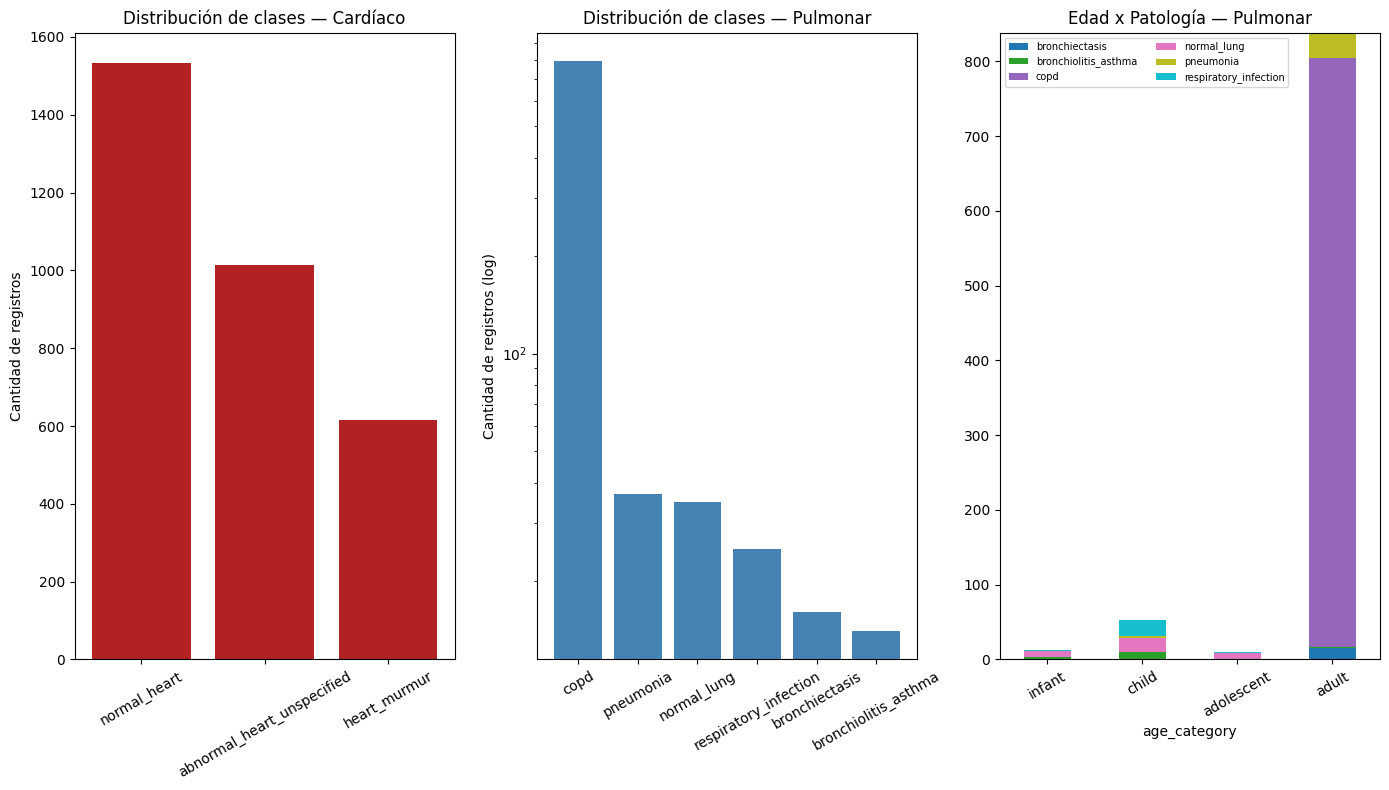

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 8))
axes = axes.flatten()

# 1. Distribución de clases - Cardíaco
cardiac_counts = df[df["sound_type"] == "cardiac"]["pathology_label"].value_counts()
axes[0].bar(cardiac_counts.index, cardiac_counts.values, color="firebrick")
axes[0].set_title("Distribución de clases — Cardíaco")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Cantidad de registros")

# 2. Distribución de clases - Pulmonar (log scale por el desbalance con COPD)
pulmonary_counts = df[df["sound_type"] == "pulmonary"]["pathology_label"].value_counts()
axes[1].bar(pulmonary_counts.index, pulmonary_counts.values, color="steelblue")
axes[1].set_title("Distribución de clases — Pulmonar")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_yscale("log")
axes[1].set_ylabel("Cantidad de registros (log)")

# 3. Edad x patología - Pulmonar (donde vimos el patrón más marcado)
age_order = ["neonate", "infant", "child", "adolescent", "adult"]
pulm_age = pd.crosstab(pulmonary["age_category"], pulmonary["pathology_label"])
pulm_age = pulm_age.reindex(age_order).dropna(how="all")
pulm_age.plot(kind="bar", stacked=True, ax=axes[2], colormap="tab10")
axes[2].set_title("Edad x Patología — Pulmonar")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend(fontsize=7, ncol=2)

# axes[-1].axis("off")

plt.tight_layout()
plt.savefig("eda_resumen.png", dpi=150)
plt.show()

### Análisis de sonidos

Habiendo analizado los datos del .csv voy a pasar a analizar los distintos tipos de sonido. Lo primero que voy a hacer es armar una muestra estratificada por pathology_label (unos 3-5 ejemplos por clase, priorizando las clases chicas para no perdernos ninguna) y cargar los WAVs:

In [32]:
import librosa
import librosa.display
import numpy as np

AUDIO_DIR = Path("../../data/unified/audio")
N_POR_CLASE = 3

sample_ids = (
    df.groupby("pathology_label", group_keys=False)
      .sample(n=N_POR_CLASE, random_state=42)
)

print(f"Muestra total: {len(sample_ids)} archivos")
sample_ids[["file_id", "pathology_label", "sound_type", "sample_rate_hz", "duration_sec"]]

Muestra total: 27 archivos


,file_id,pathology_label,sound_type,sample_rate_hz,duration_sec
1733,CIR_01833.wav,abnormal_heart_unspecified,cardiac,4000,NaN
1377,CIR_01477.wav,abnormal_heart_unspecified,cardiac,4000,NaN
2866,CIR_02966.wav,abnormal_heart_unspecified,cardiac,4000,NaN
3922,ICB_04022.wav,bronchiectasis,pulmonary,4000,NaN
4036,ICB_04136.wav,bronchiectasis,pulmonary,4000,NaN
3925,ICB_04025.wav,bronchiectasis,pulmonary,4000,NaN
4038,ICB_04138.wav,bronchiolitis_asthma,pulmonary,4000,NaN
4039,ICB_04139.wav,bronchiolitis_asthma,pulmonary,4000,NaN
3980,ICB_04080.wav,bronchiolitis_asthma,pulmonary,4000,NaN
3702,ICB_03802.wav,copd,pulmonary,44100,NaN


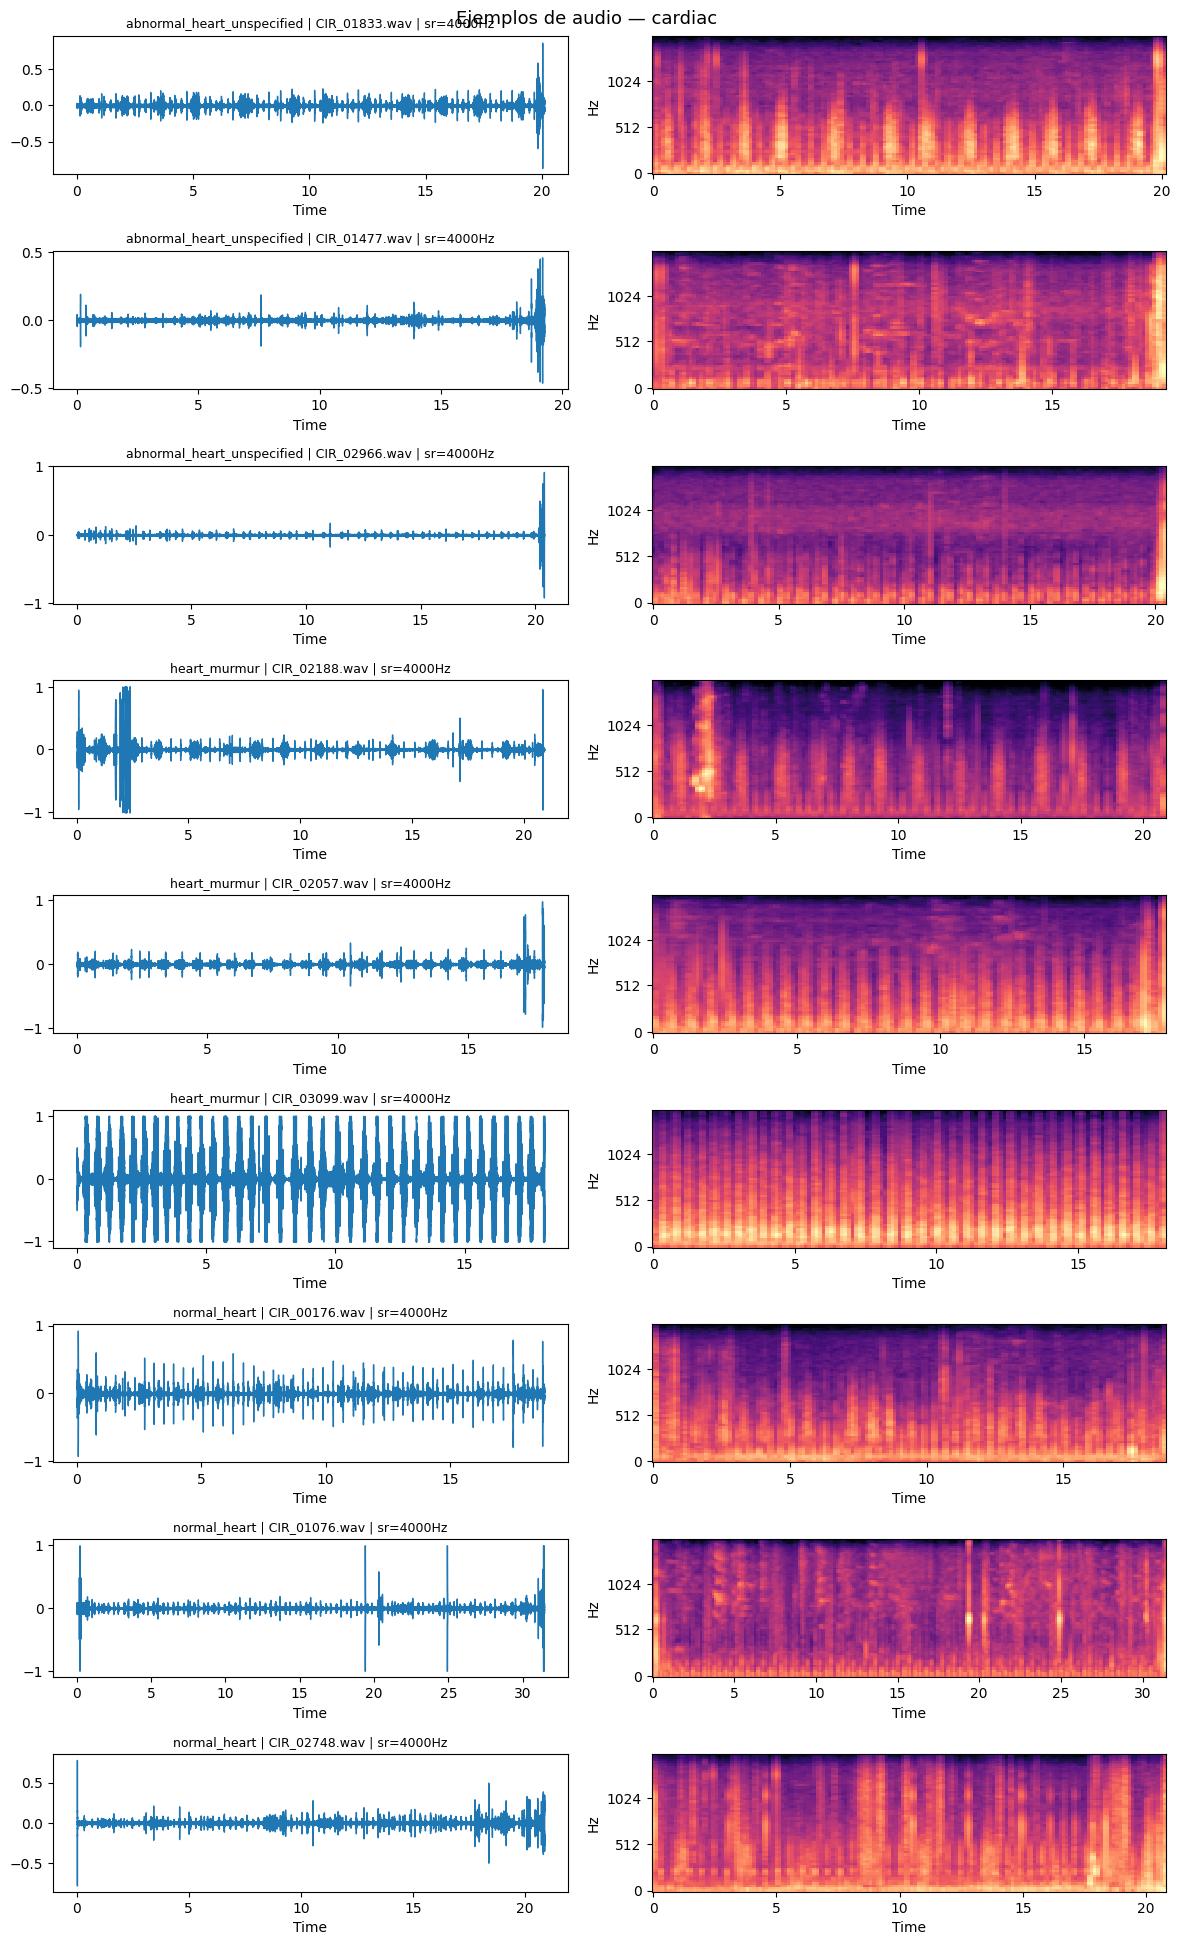

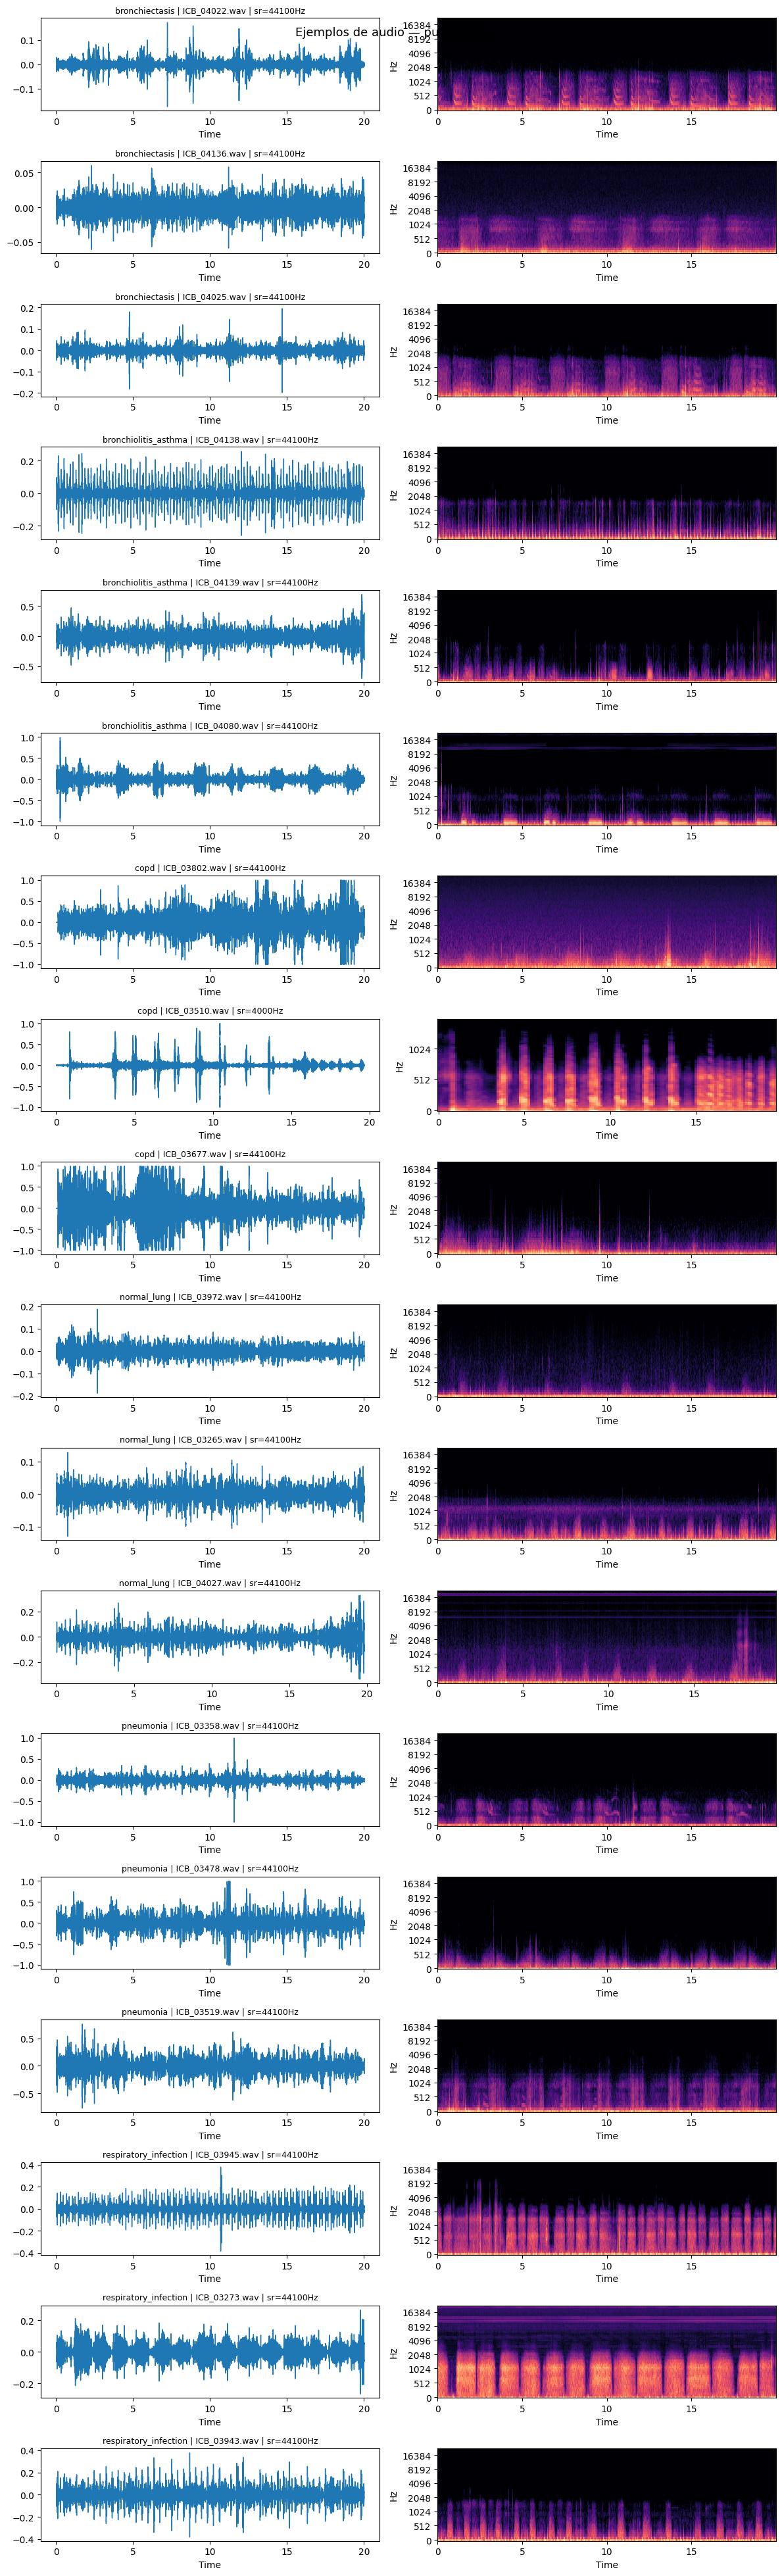

In [ ]:
def plot_audio_examples(row, ax_wave, ax_spec):
    wav_path = AUDIO_DIR / row["file_id"]
    y, sr = librosa.load(wav_path, sr=None)  # sr=None respeta el sample rate original

    # Forma de onda
    librosa.display.waveshow(y, sr=sr, ax=ax_wave)
    ax_wave.set_title(f"{row['pathology_label']} | {row['file_id']} | sr={sr}Hz", fontsize=9)

    # Espectrograma Mel
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=ax_spec)
    return img

# Graficamos por sound_type para no mezclar escalas de frecuencia muy distintas
for stype in ["cardiac", "pulmonary"]:
    sub = sample_ids[sample_ids["sound_type"] == stype].reset_index(drop=True)
    n = len(sub)
    fig, axes = plt.subplots(n, 2, figsize=(12, 2.2 * n))
    for i, row in sub.iterrows():
        plot_audio_examples(row, axes[i, 0], axes[i, 1])
    fig.suptitle(f"Ejemplos de audio - {stype}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"eda_audio_{stype}.png", dpi=130)
    plt.show()

#### Hallazgos

* **Rango de frecuencias:** en los espectrogramas pulmonares (sr nativo hasta 44100 Hz), toda la energía relevante está concentrada por debajo de ~2048 Hz; el resto del espectro (hasta 16384 Hz) no muestra contenido útil. Sin embargo, se observaron algunos picos que exceden los 4 kHz. Creo que lo mas conveniente es hacer un downsampling de las señales respiratorias a 4000 Hz para equiparar el SR de las cardíacas (Quizas convenga llevar todo a 8000 Hz para que estos picos puedan entrar)
* **Periodicidad cardíaca:** se observa un patrón vertical repetitivo muy marcado en los espectrogramas cardíacos, correspondiente a los ciclos S1-S2. Queda como idea para la etapa de preprocesamiento: considerar segmentación por ciclo cardíaco en vez de ventanas de tiempo fijas.
* **Diferencias de amplitud entre clases:** algunas clases pulmonares (bronchiolitis_asthma, copd, pneumonia) muestran amplitudes bruscamente mayores (~±1.0) que otras (bronchiectasis, normal_lung, ~±0.05–0.2). Pendiente de verificar si esta diferencia de ganancia correlaciona con la clase (posible atajo espurio) o es incidental a la sesión de grabación.

#### Decisiones de preprocesamiento

* Filtrado: pasabanda cortando por encima de ~4096 Hz (aplicar antes del resample para evitar aliasing)
* Resample: frecuencia objetivo de ~8192 Hz
* Normalización de amplitud: por RMS (más robusto que min-max/pico ante ruido puntual)
* Duración/ventaneo: ventaneo con solapamiento (sliding window) para las clases minoritarias, en vez de solo truncar (genera más ejemplos de entrenamiento)